# Getting Setup and what we are covering

Let's explore an example PyTorch end-to-end workflow.   

Resources :
* Ground truth notebook - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/video_notebooks/02_pytorch_classification_video.ipynb
* Book version - https://www.learnpytorch.io/01_pytorch_workflow/
* Ask a question - https://github.com/mrdbourke/pytorch-deep-learning/discussions

In [1]:
what_we_are_covering = {
    1 : "data (prepare and load)",
    2 : "build modle", # an ML or DL model building in PyTorch
    3 : "fitting the model to the data (training)",
    4 : "making predictions and evaluating a model (inference)", # look deeper into improving through experimentation (later)
    5 : "saving and loading a model",
    6 : "putting it all together"
} 

what_we_are_covering

{1: 'data (prepare and load)',
 2: 'build modle',
 3: 'fitting the model to the data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.6.0'

Documentation - https://docs.pytorch.org/docs/stable/nn.html

Other interesting documentations :
* https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html
* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

`torch.nn`

These are the basic building blocks for graphs. By `graphs`, here, we really mean, computational graphs. We combine multiple torch.nn components together to build neural networks.

# (1) Data (prepare and load)

**Creating a simple dataset using the linear regression formula.**

Data can be almost anything.... in machine learning. Such as:

* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data...)
* Audios like songs or podcasts
* DNA
* Text  

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

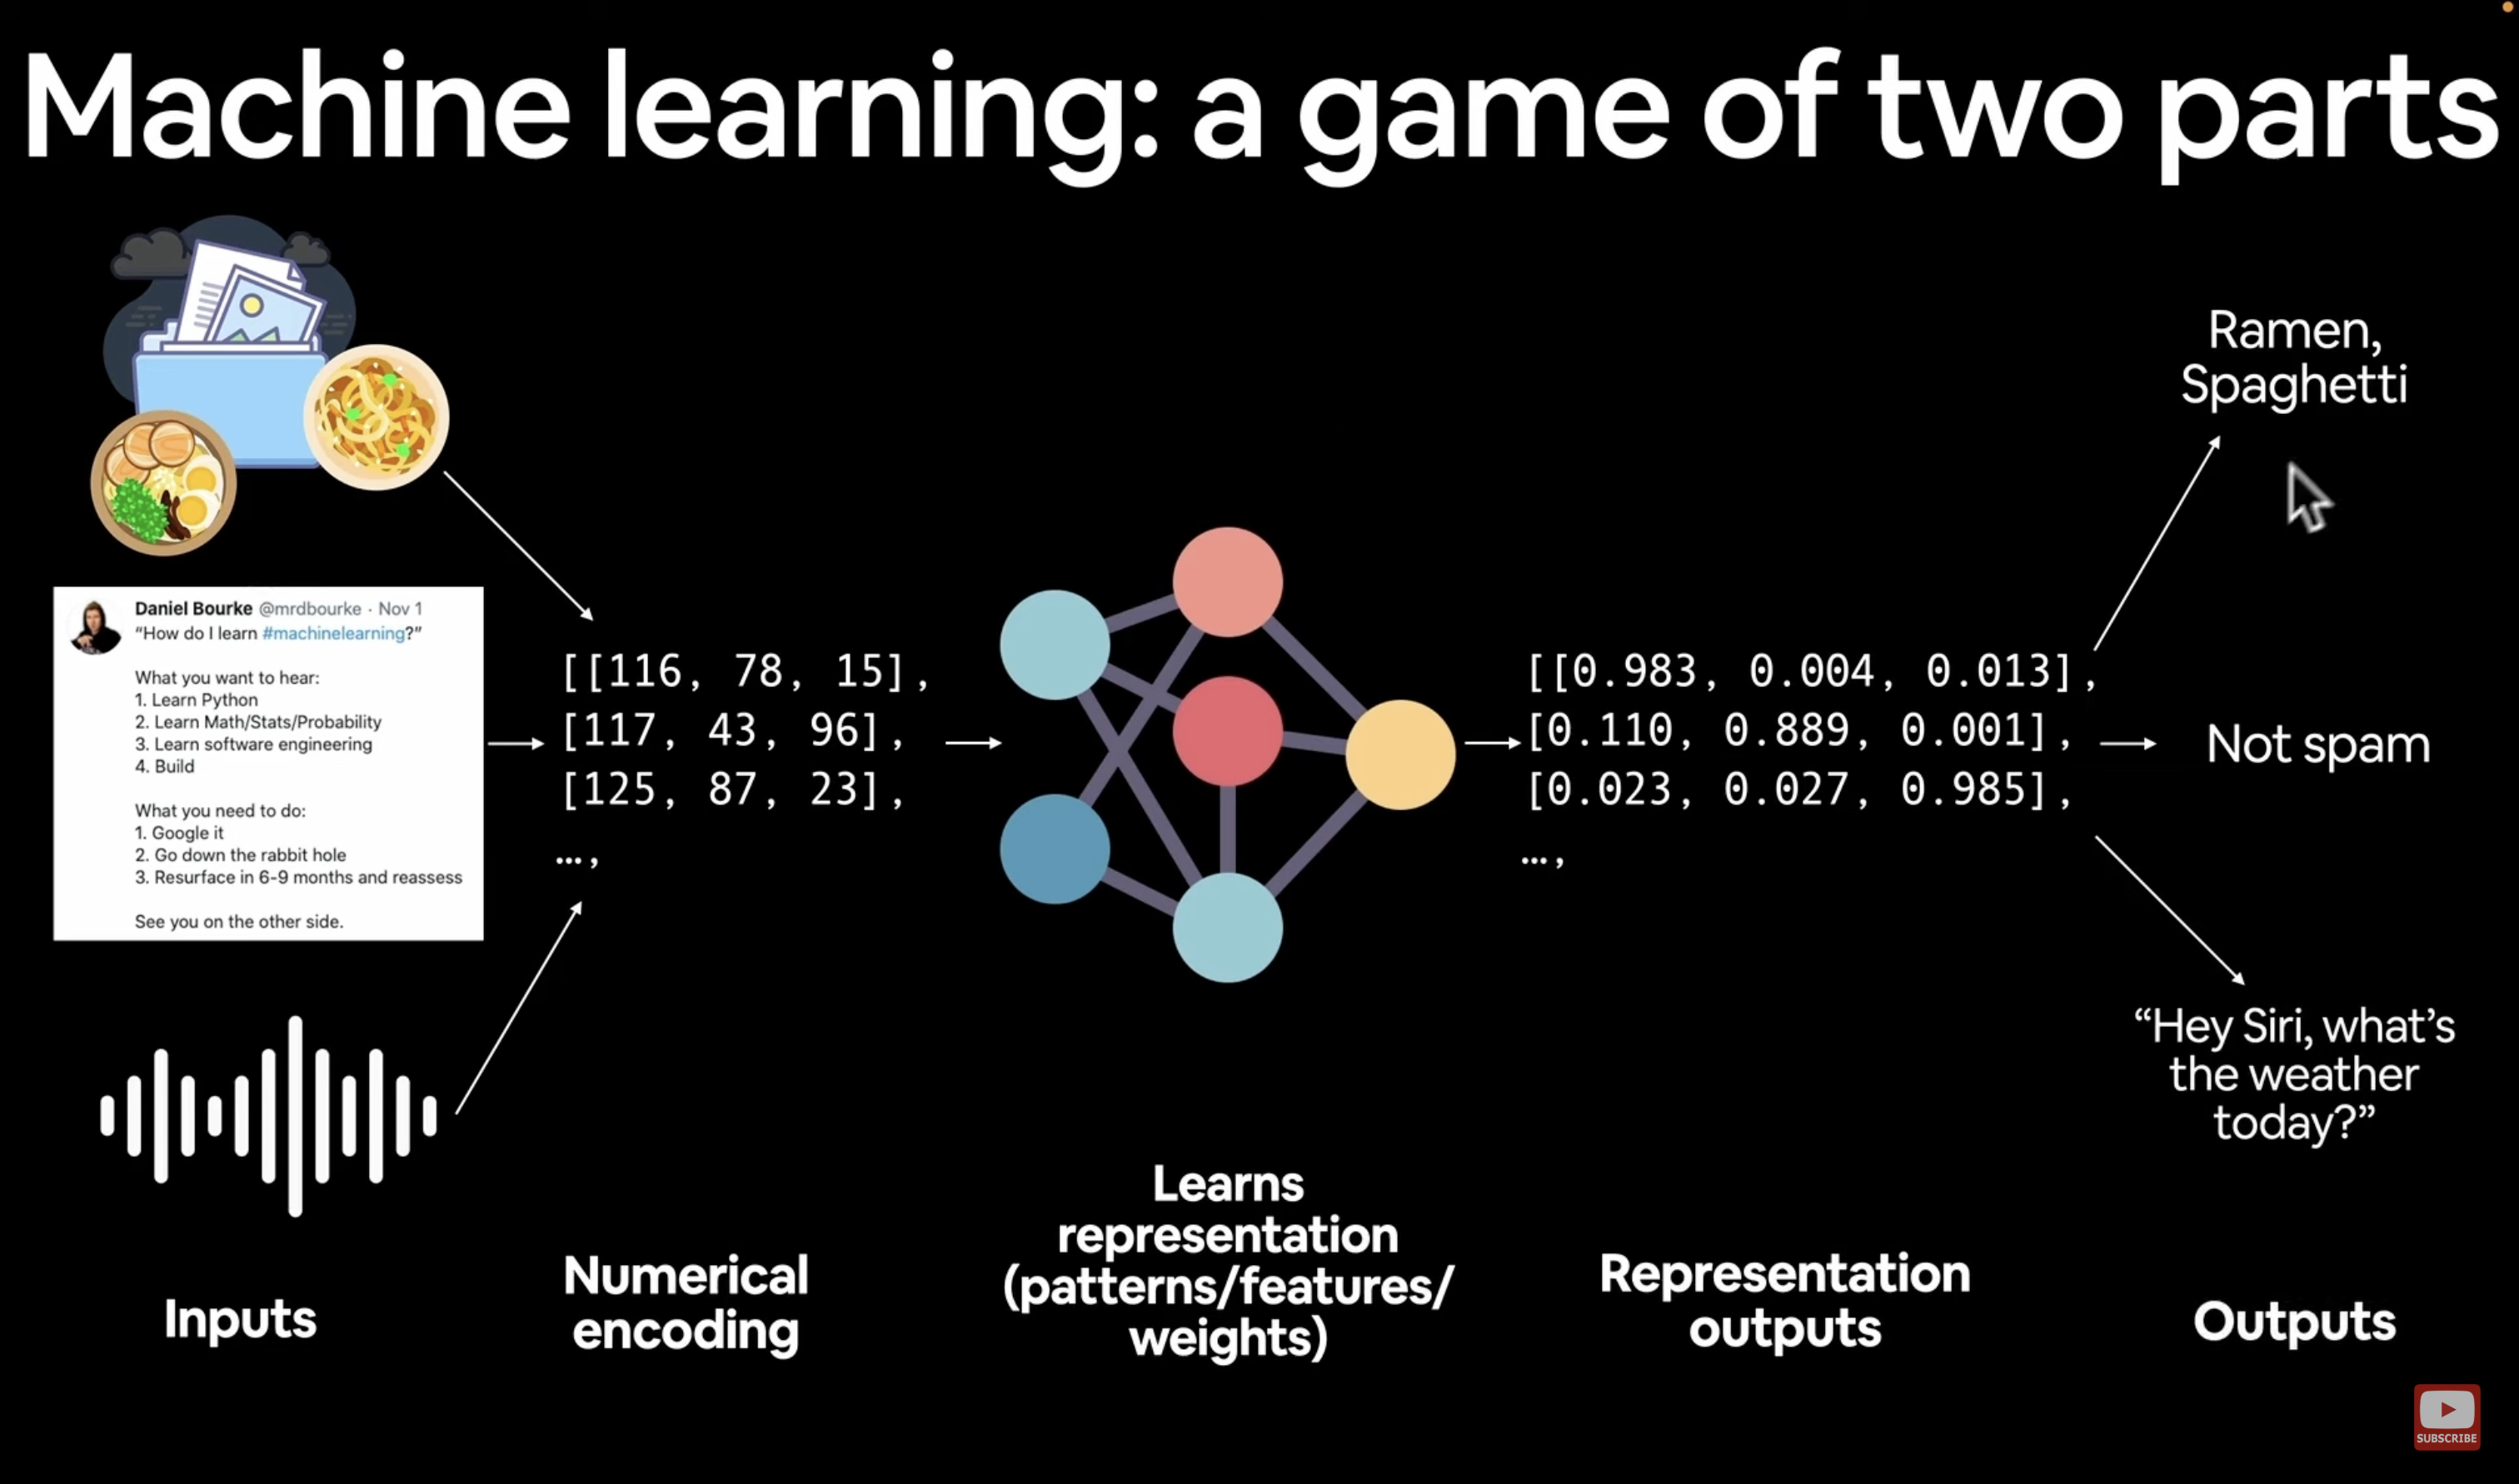

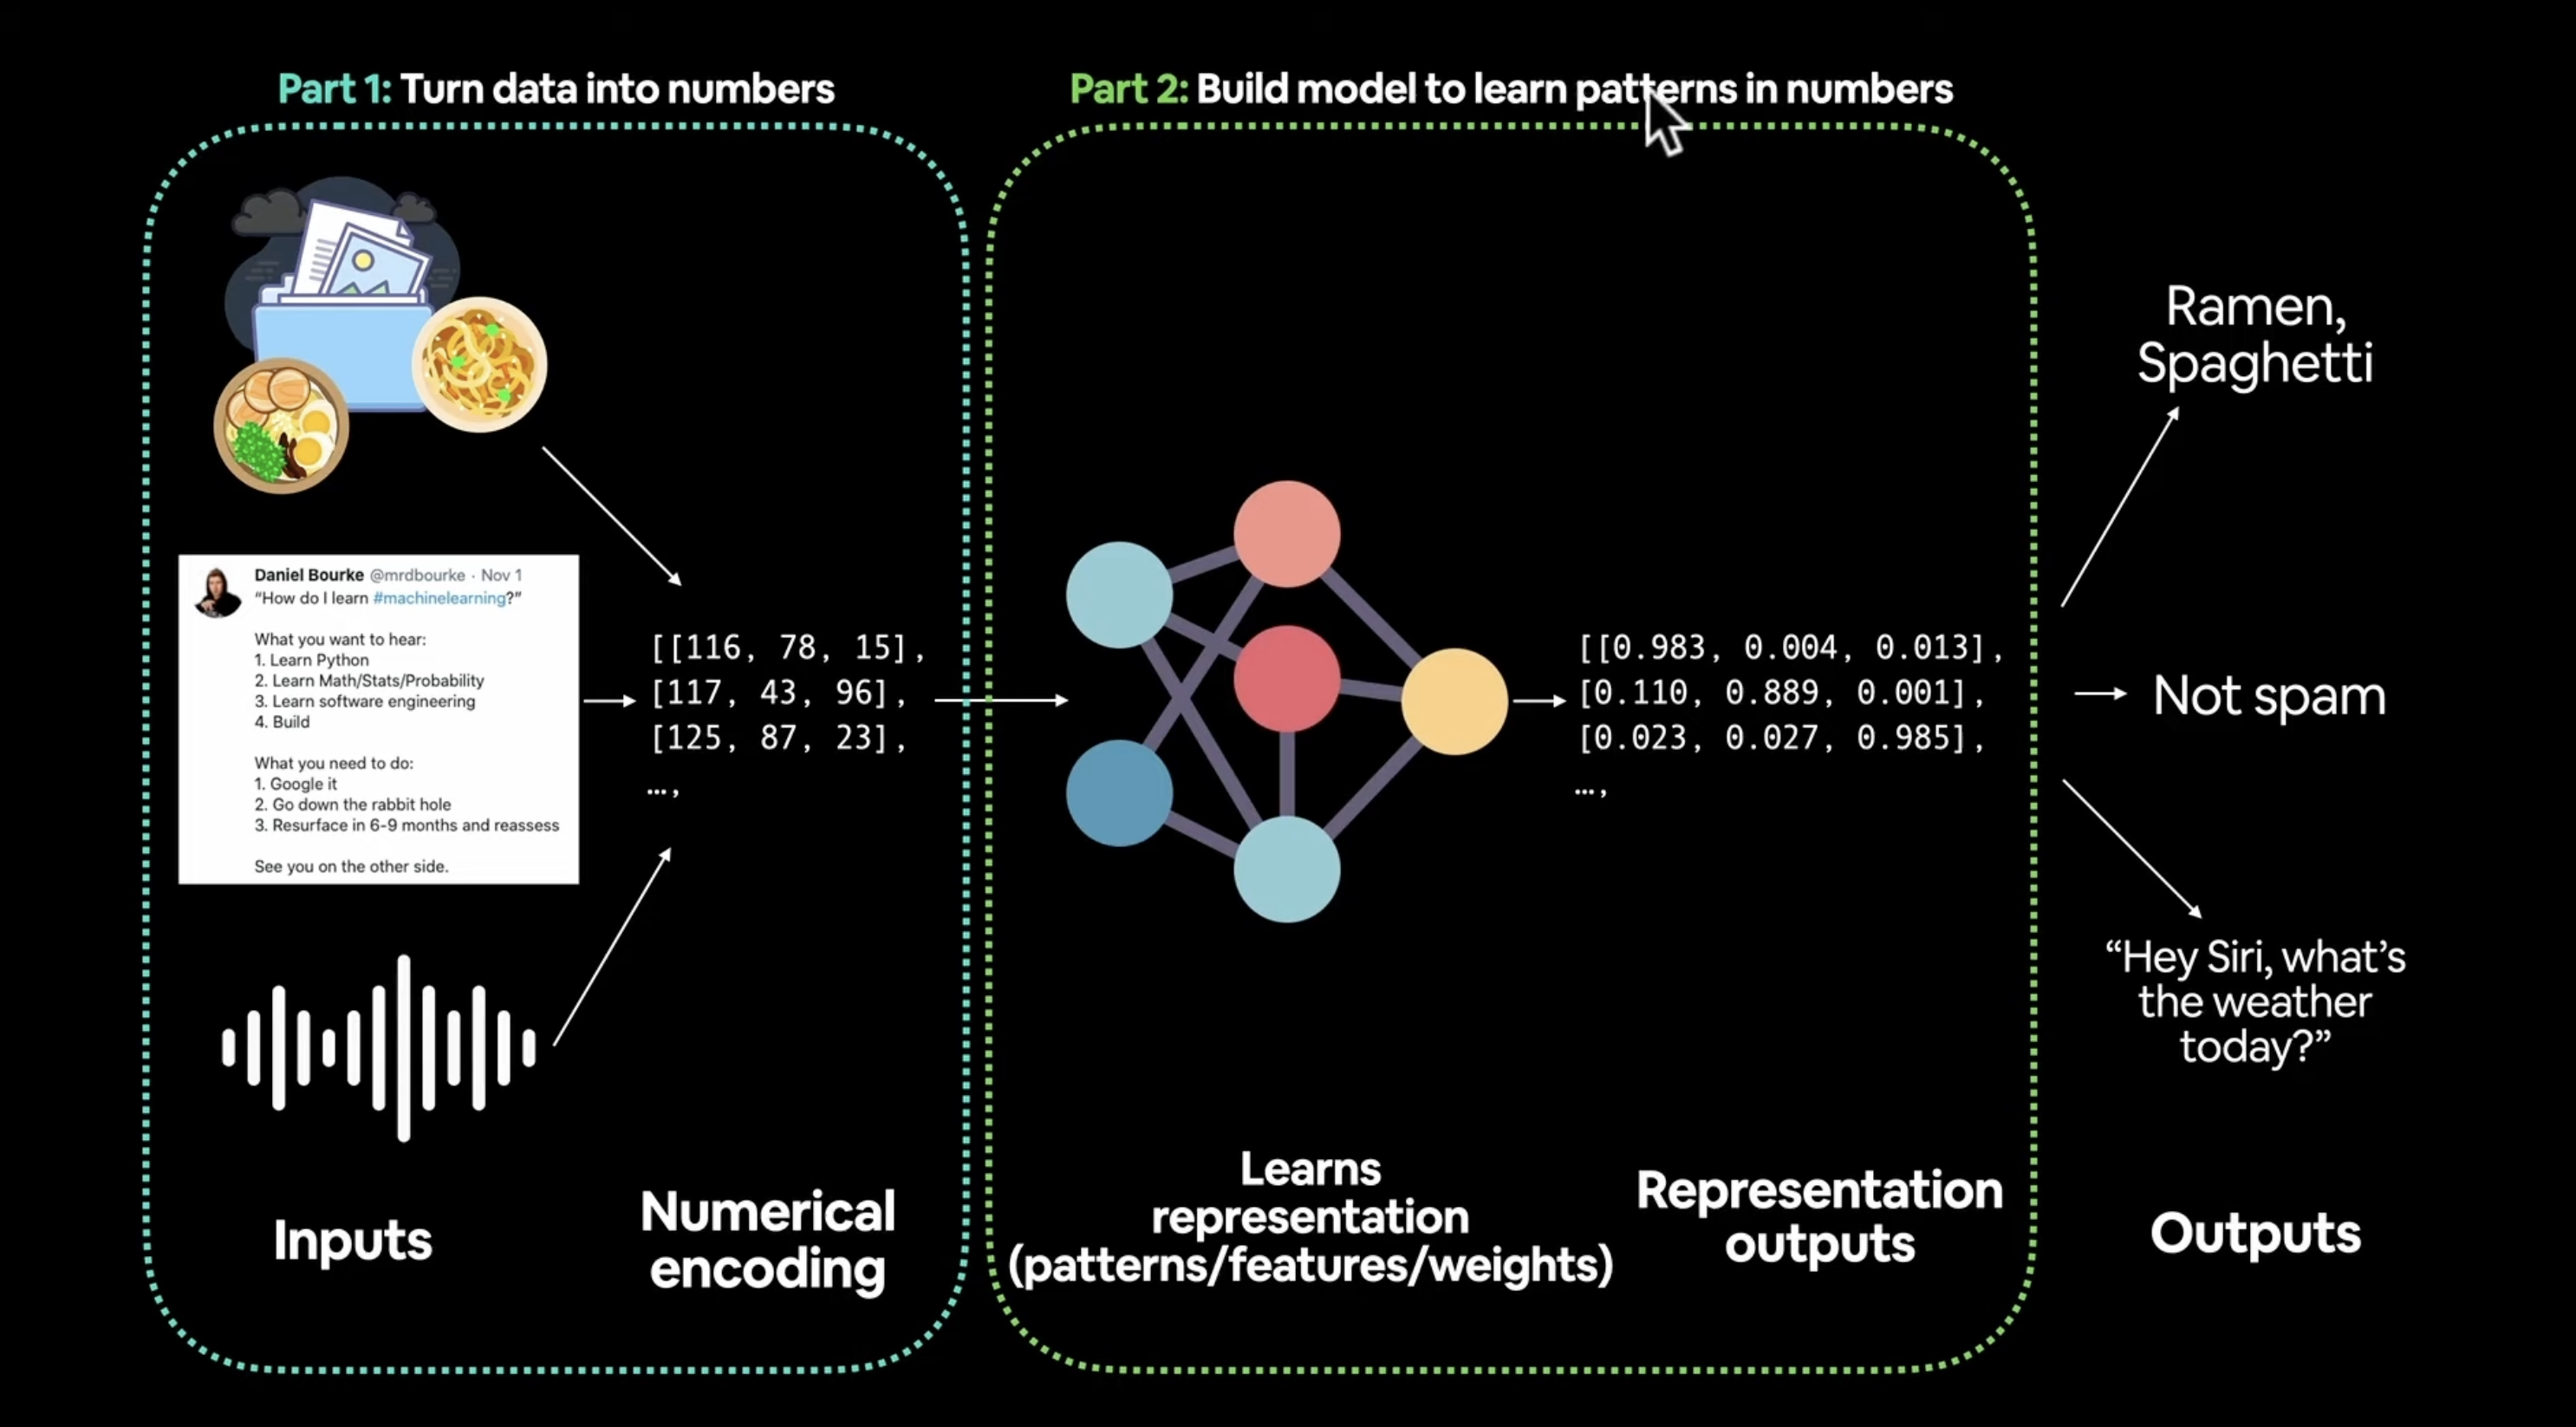

To showcase this, let's create some *known* data using the Linear regression formula.

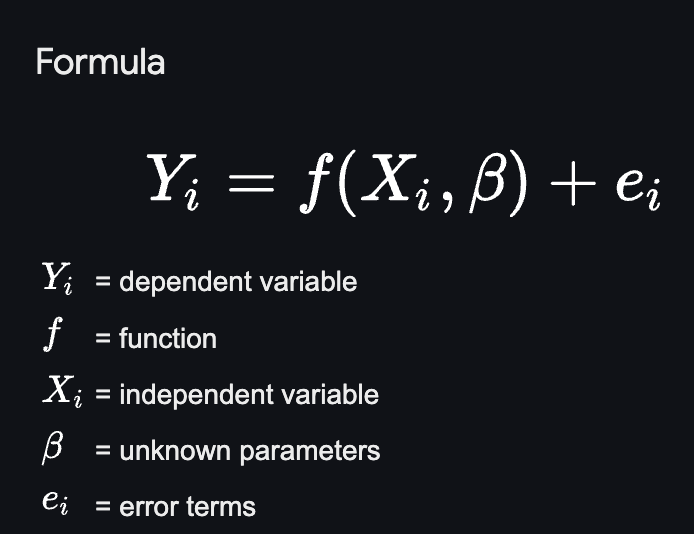

* Slope is also known as Gradient.

We'll use a linear regression formula to make a straight line with *known* **parameters**.

A parameter is something that the model learns.

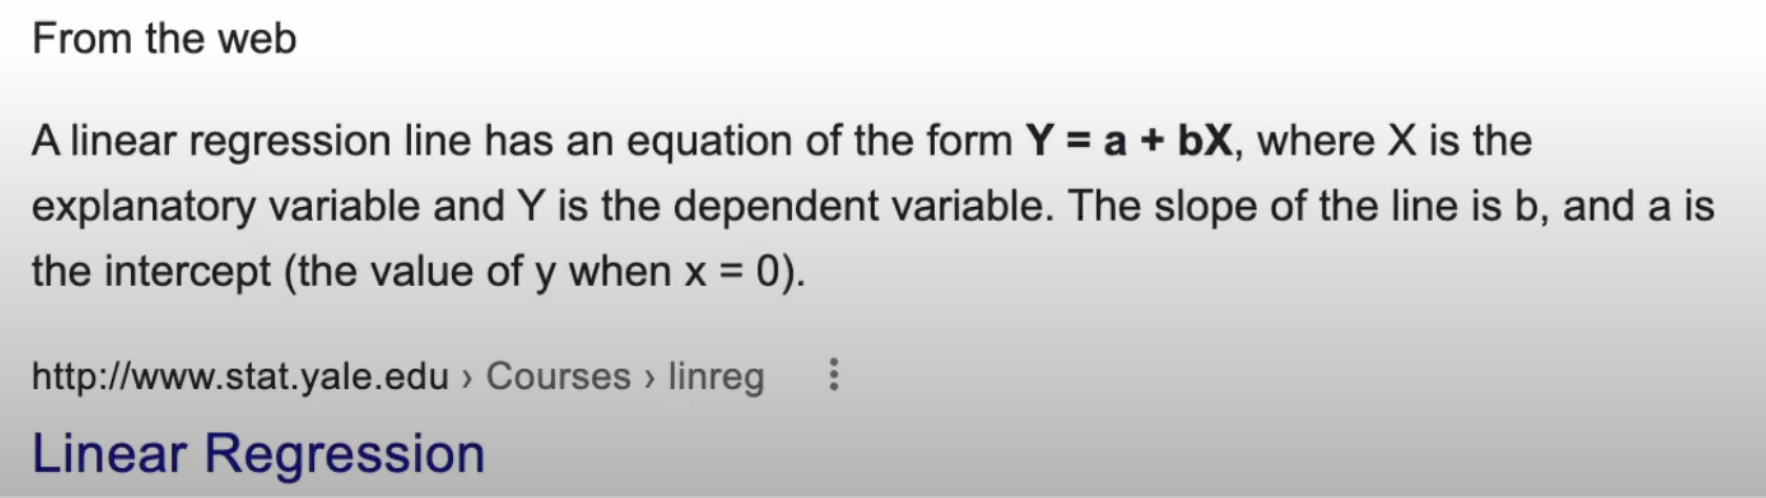

In [4]:
# Create known parameters 
weight = 0.7 # b (in the equation above)
bias = 0.3 # a (in the equation above)

We know these numbers. We're going to build a model that is able to estimate these numbers.

In [5]:
# Create some data 
start = 0
end = 1
step = 0.02

In [14]:
x1 = torch.arange(start, end, step)
# x1,
x1.shape

torch.Size([50])

In [17]:
x1

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
        0.9000, 0.9200, 0.9400, 0.9600, 0.9800])

In [15]:
y1 = weight * x1 + bias
y1.shape

torch.Size([50])

In [16]:
y1

tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
        0.4260, 0.4400, 0.4540, 0.4680, 0.4820, 0.4960, 0.5100, 0.5240, 0.5380,
        0.5520, 0.5660, 0.5800, 0.5940, 0.6080, 0.6220, 0.6360, 0.6500, 0.6640,
        0.6780, 0.6920, 0.7060, 0.7200, 0.7340, 0.7480, 0.7620, 0.7760, 0.7900,
        0.8040, 0.8180, 0.8320, 0.8460, 0.8600, 0.8740, 0.8880, 0.9020, 0.9160,
        0.9300, 0.9440, 0.9580, 0.9720, 0.9860])

In [20]:
x1 = torch.arange(start, end, step).unsqueeze(dim=1)
# x1, 
x1.shape

torch.Size([50, 1])

In [21]:
x1

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [22]:
y1 = weight * x1 + bias
y1.shape

torch.Size([50, 1])

In [23]:
y1

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460],
        [0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [25]:
X = torch.arange(start, end, step).unsqueeze(dim=1) # X is capital - since, in ML, you'll find is a matrix or a tensor
y = weight * X + bias # y (lowercase) - represents a vector

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [26]:
len(X), len(y)

(50, 50)

Build a model to learn some values - look at the `X` values & learn what the associated `y` value is, essentially, the relationship between them.   

The whole premise of ML is the fact that you would have a set of inputs and outputs, with no idea about the relationship between them. So, the whole premise of ML is to learn a representation of the input and how it maps to the output, by inferring patterns in the data

We'll need `unsqueeze()` for later on, when we're doing models.

# (2) Splitting our data into Training and Test sets

One of the most important concepts in ML, in general.

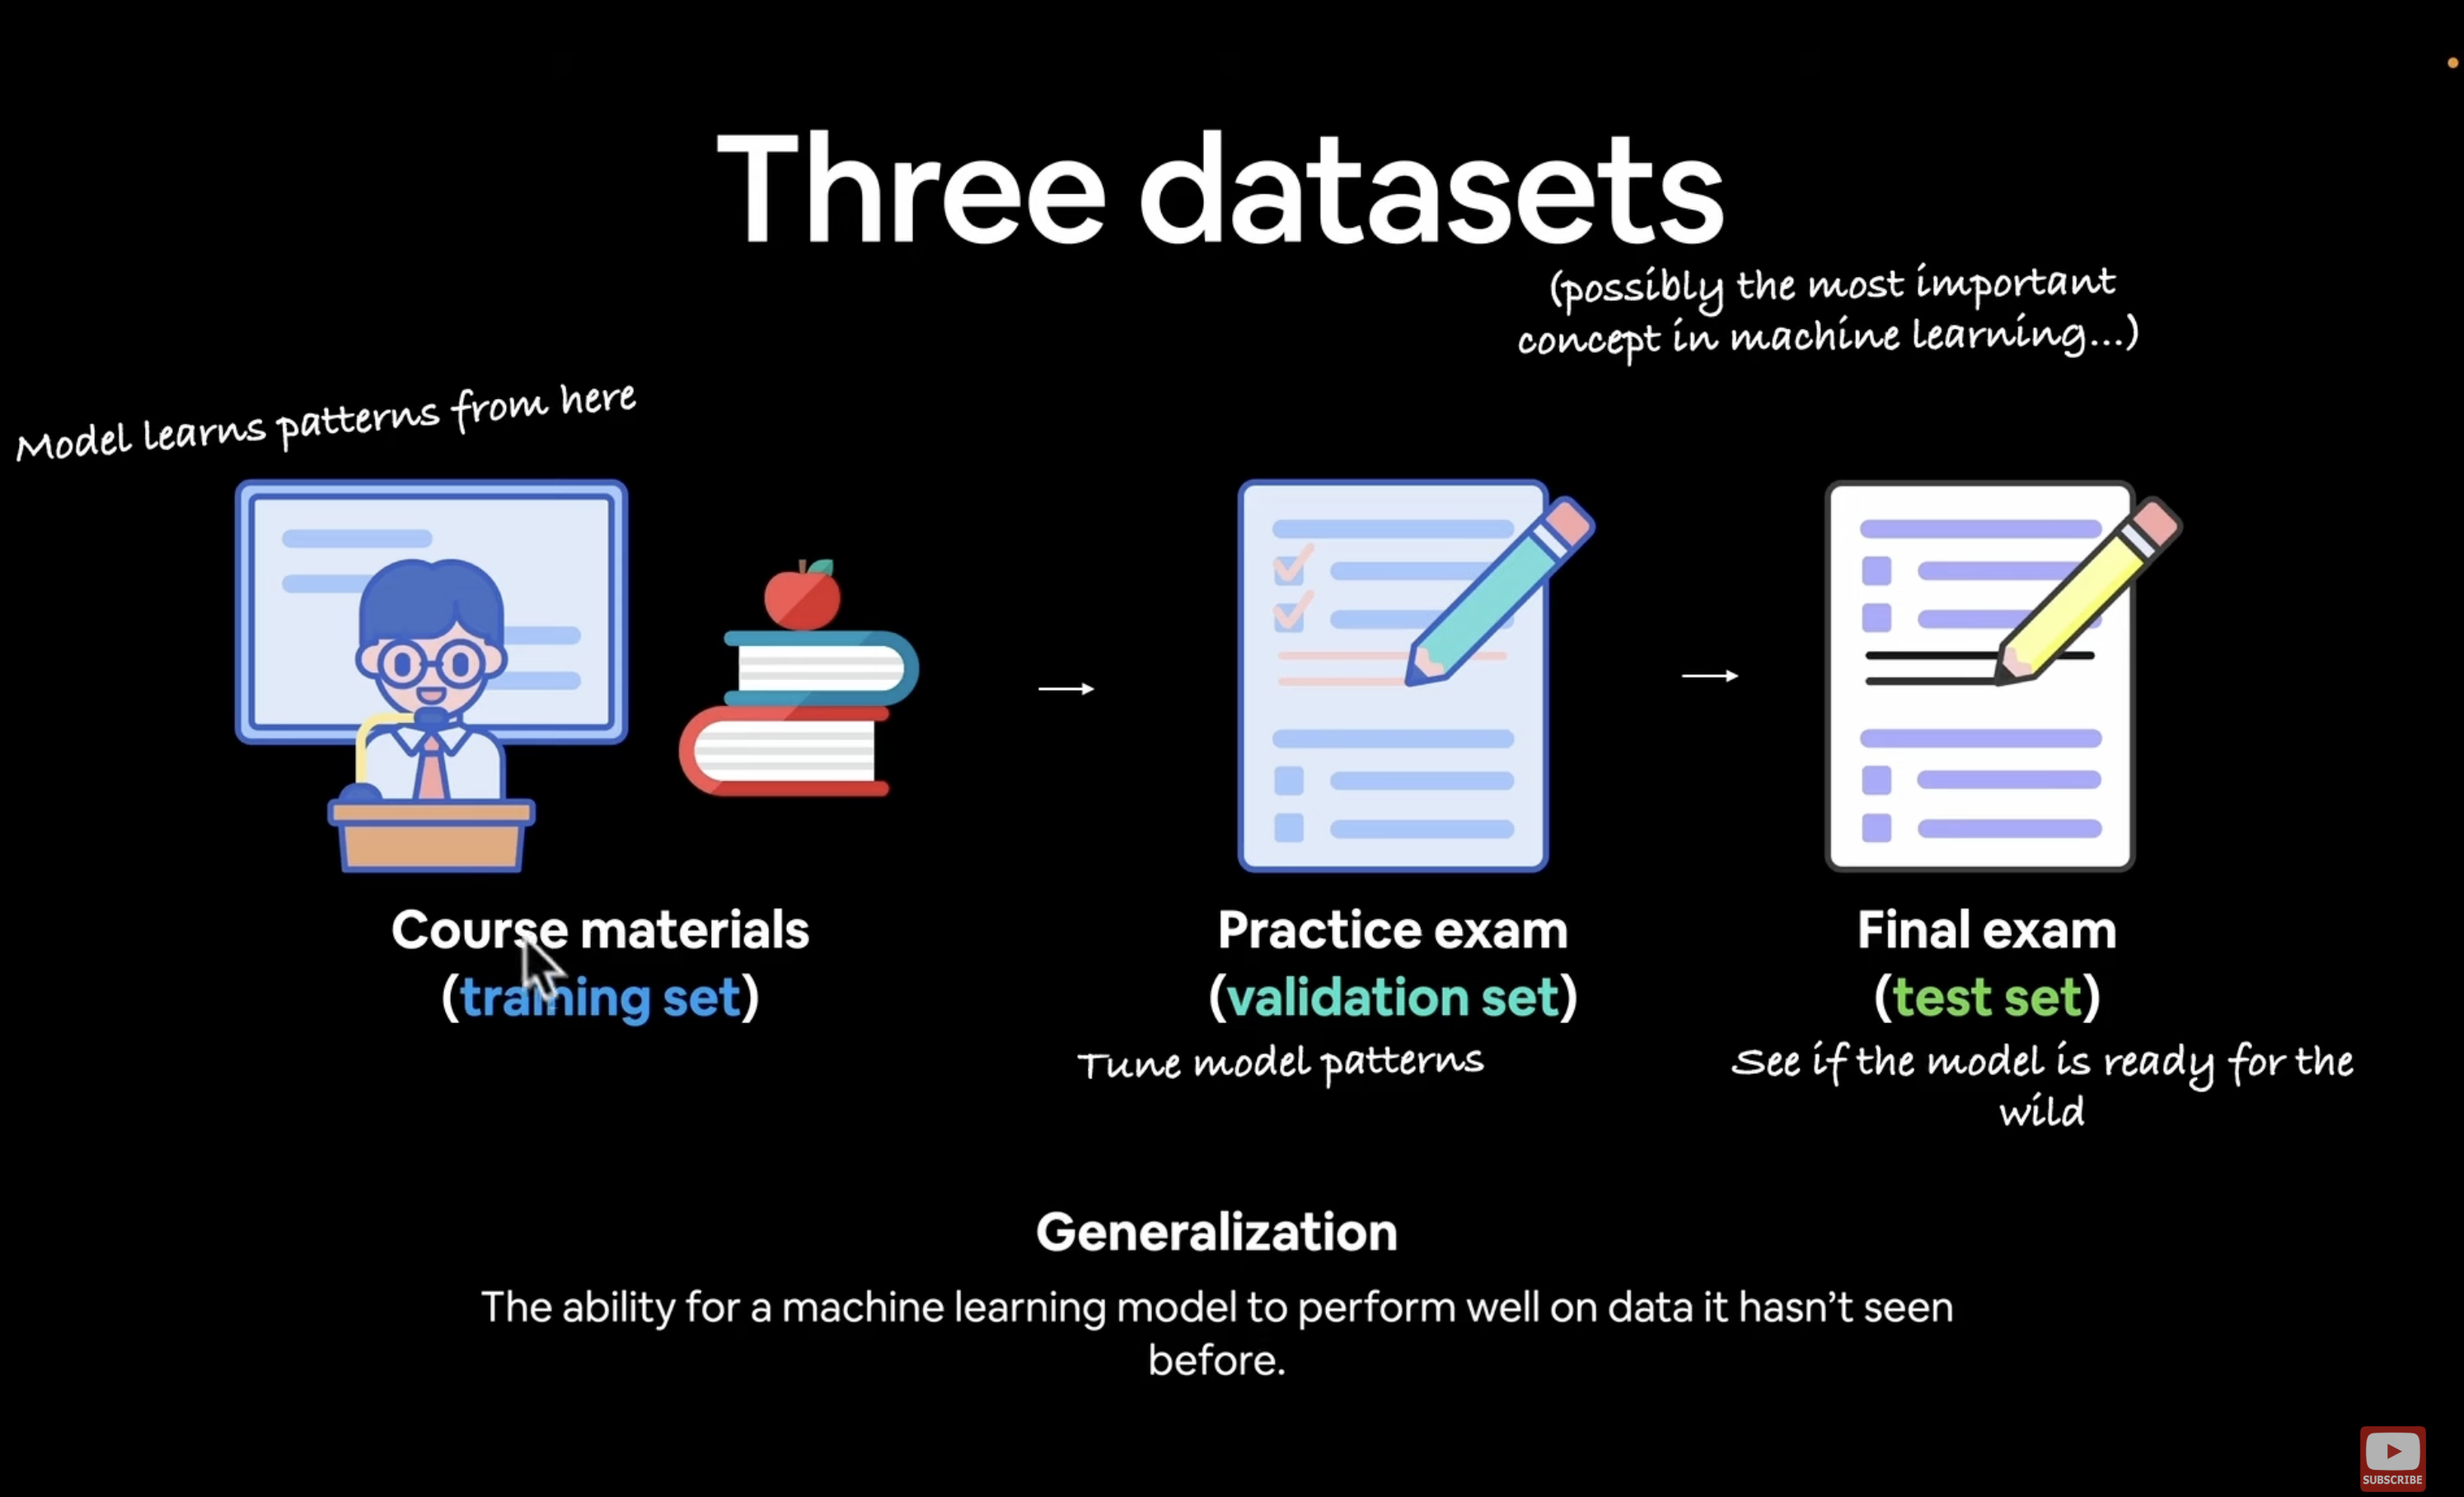

1. **Training set**
2. **Validation set**
    - data which helps in tuning our model based on the practice set.
    - if it doesn't do too well, we adjust it a bit and we re-train it & then it does better.
    - we don't always need a validation set - they are for model tuning.
3. **Test set**
    - adaptation to unseen data; to test for our model's generalization.

**Generalization** : The ability for a ML model to perform well on data it hasn't seen before.

In [27]:
# Creating known parameters
weight = 0.7
bias = 0.3

# Creating dataset
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

Let's create a training and test set with our data.

In [28]:
# Create a train/test split
# splitting as 80-20
train_split = int(0.8*len(X))
train_split

40

In [29]:
X_train, y_train = X[:train_split] , y[:train_split] # train split
X_test, y_test = X[train_split:], y[train_split:] # test split

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

One of the popular methods to perform data split is `scikit learn train test split` which adds a little bit of randomness into splitting the data : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

# (3) Building a function to visualize our data

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [32]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):

    """
    Plots training data, test data and compares predictions.
    """

    plt.figure(figsize=(10,7)) # a good dimension for matplotlib 

    # Plot training data in blue    
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green (ugh no), black
    plt.scatter(test_data, test_labels, c="black", s=4, label="Testing data")

    # Are there predictions
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    
    # Show the legend
    plt.legend(prop={"size":14})

More on `plt.scatter` : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

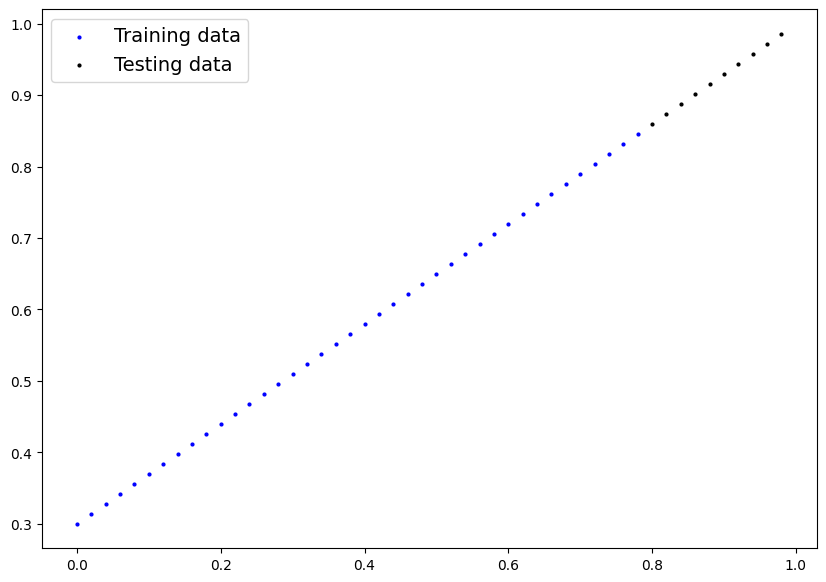

In [33]:
plot_predictions()

Our data does have a pattern, as can be seen above. We are now going to build a model to try and learn the pattern of these blue dots so that if we fed our model with the data, the X test data could be accurately predicted.

# (4) Creating our first PyTorch model for Linear Regression

Recommended pre-requisite on OOP (Python classes) : https://realpython.com/python-classes/

* Modules can also contain other Modules, allowing to nest them in a tree structure. --> can be staked on top of each other like lego bricks & make progressively complex neural networks as we go.
* You can assign the submodules as regular attributes 

In [ ]:
from torch import nn # nn is the building block layer for neural networks

In [ ]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # the class inherits from nn.Module <- almost everything in PyTorch inherits from nn.Module. 
    # Image nn.Module as the lego building bricks of PyTorch model
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, 
                                                requires_grad=True, 
                                                dtype=torch.float))

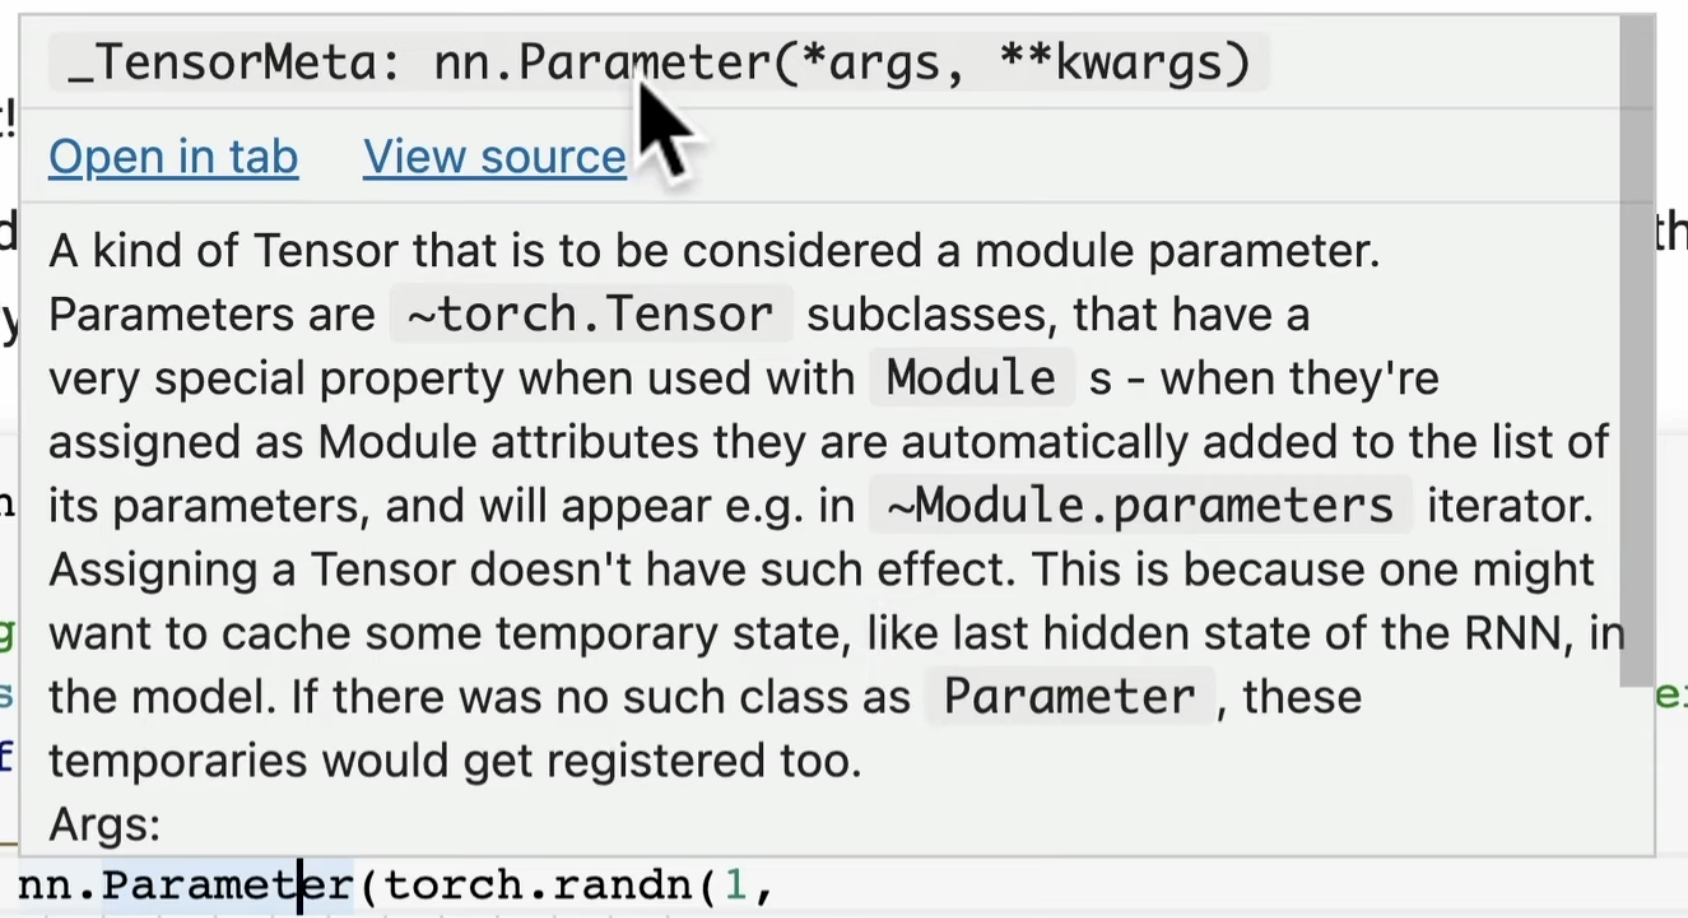